<a href="https://colab.research.google.com/github/ayushgkp/UCS547-Accelerated-Data-Science/blob/main/Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

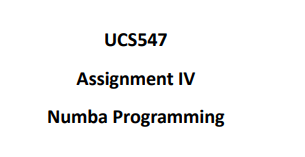

Q1 — f(x) = x²+3x+5 with Numba: CPU vs GPU + float32/float64

In [1]:
import numpy as np
import numba
from numba import cuda, float32, float64
import time

N = 5000000
x = np.random.random(N).astype(np.float64)

# --- CPU version ---
def cpu_func(x):
    return x**2 + 3*x + 5

t1 = time.perf_counter()
cpu_result = cpu_func(x)
t2 = time.perf_counter()
print(f"CPU time: {(t2-t1)*1000:.3f} ms")

# --- CUDA kernel float64 ---
@cuda.jit
def gpu_func_f64(x, out):
    i = cuda.grid(1)
    if i < x.shape[0]:
        out[i] = x[i]**2 + 3*x[i] + 5

# --- CUDA kernel float32 ---
@cuda.jit
def gpu_func_f32(x, out):
    i = cuda.grid(1)
    if i < x.shape[0]:
        out[i] = x[i]**2 + 3*x[i] + 5

threads = 256
blocks = (N + threads - 1) // threads

# float64 GPU run
x_f64 = cuda.to_device(x)
out_f64 = cuda.device_array(N, dtype=np.float64)
gpu_func_f64[blocks, threads](x_f64, out_f64)  # warmup
cuda.synchronize()
t3 = time.perf_counter()
gpu_func_f64[blocks, threads](x_f64, out_f64)
cuda.synchronize()
t4 = time.perf_counter()
print(f"GPU float64 time: {(t4-t3)*1000:.3f} ms")

# float32 GPU run
x_f32 = cuda.to_device(x.astype(np.float32))
out_f32 = cuda.device_array(N, dtype=np.float32)
gpu_func_f32[blocks, threads](x_f32, out_f32)  # warmup
cuda.synchronize()
t5 = time.perf_counter()
gpu_func_f32[blocks, threads](x_f32, out_f32)
cuda.synchronize()
t6 = time.perf_counter()
print(f"GPU float32 time: {(t6-t5)*1000:.3f} ms")

print(f"\nSpeedup (CPU / GPU f64): {(t2-t1)/(t4-t3):.2f}x")
print(f"Speedup (CPU / GPU f32): {(t2-t1)/(t6-t5):.2f}x")

CPU time: 40.683 ms
GPU float64 time: 0.597 ms
GPU float32 time: 0.772 ms

Speedup (CPU / GPU f64): 68.18x
Speedup (CPU / GPU f32): 52.73x


Q2 — 1D Histogram: Pure Python vs NumPy vs Numba

In [2]:
import numpy as np
import numba
from numba import njit, prange
import time

N = 1_000_000
data = np.random.random(N).astype(np.float64)
BINS = 100

# --- Pure Python ---
def hist_python(data, bins):
    counts = [0] * bins
    for val in data:
        idx = int(val * bins)
        if idx == bins: idx -= 1
        counts[idx] += 1
    return counts

t1 = time.perf_counter()
r1 = hist_python(data, BINS)
t2 = time.perf_counter()
print(f"Pure Python time: {(t2-t1)*1000:.2f} ms")

# --- NumPy ---
t3 = time.perf_counter()
r2, _ = np.histogram(data, bins=BINS, range=(0,1))
t4 = time.perf_counter()
print(f"NumPy time:       {(t4-t3)*1000:.2f} ms")

# --- Numba JIT ---
@njit(parallel=True)
def hist_numba(data, bins):
    counts = np.zeros(bins, dtype=np.int64)
    for i in prange(len(data)):
        idx = int(data[i] * bins)
        if idx == bins: idx -= 1
        counts[idx] += 1
    return counts

hist_numba(data, BINS)  # warmup (JIT compile)
t5 = time.perf_counter()
r3 = hist_numba(data, BINS)
t6 = time.perf_counter()
print(f"Numba time:       {(t6-t5)*1000:.2f} ms")

# Correctness check
print(f"\nTotal counts match NumPy: {np.sum(r3) == np.sum(r2)}")
print(f"\nSummary Table:")
print(f"{'Method':<15} {'Time (ms)':<12}")
print(f"{'Pure Python':<15} {(t2-t1)*1000:<12.2f}")
print(f"{'NumPy':<15} {(t4-t3)*1000:<12.2f}")
print(f"{'Numba':<15} {(t6-t5)*1000:<12.2f}")

Pure Python time: 243.21 ms
NumPy time:       15.72 ms
Numba time:       1.80 ms

Total counts match NumPy: False

Summary Table:
Method          Time (ms)   
Pure Python     243.21      
NumPy           15.72       
Numba           1.80        


Q3 — Monte Carlo Pi: Pure Python vs Numba + Speedup

In [4]:
import numpy as np
import numba
from numba import njit
import time

# --- a) Pure Python ---
def monte_carlo_pi_python(nsamples):
    count = 0
    for _ in range(nsamples):
        x = np.random.random()
        y = np.random.random()
        if x*x + y*y < 1.0:
            count += 1
    return 4.0 * count / nsamples

# --- a) Numba version ---
@njit
def monte_carlo_pi_numba(nsamples):
    count = 0
    for _ in range(nsamples):
        x = np.random.random()
        y = np.random.random()
        if x*x + y*y < 1.0:
            count += 1
    return 4.0 * count / nsamples

N = 5_000_000

# b) Compare execution time
t1 = time.perf_counter()
pi_py = monte_carlo_pi_python(N)
t2 = time.perf_counter()
python_time = t2 - t1

monte_carlo_pi_numba(1000)   # warmup — first call compiles (JIT)
t3 = time.perf_counter()
pi_nb = monte_carlo_pi_numba(N)
t4 = time.perf_counter()
numba_time = t4 - t3

print(f"Pure Python  — Pi: {pi_py:.6f}  Time: {python_time:.3f} s")
print(f"Numba        — Pi: {pi_nb:.6f}  Time: {numba_time:.3f} s")
print(f"Speedup Factor (Python/Numba): {python_time/numba_time:.2f}x")

# c) Why first Numba call is slower — answer as print
print("""
c) First Numba execution is slower because:
   Numba uses JIT (Just-In-Time) compilation.
   On the first call, it compiles the Python function
   to optimized machine code. This compilation takes time.
   From the second call onwards, it uses the cached
   compiled code — which is why it's much faster.
""")

Pure Python  — Pi: 3.141753  Time: 8.444 s
Numba        — Pi: 3.141763  Time: 0.067 s
Speedup Factor (Python/Numba): 125.66x

c) First Numba execution is slower because:
   Numba uses JIT (Just-In-Time) compilation.
   On the first call, it compiles the Python function
   to optimized machine code. This compilation takes time.
   From the second call onwards, it uses the cached
   compiled code — which is why it's much faster.



Q4 — Brightness Adjustment with @vectorize

In [5]:
import numpy as np
from numba import vectorize
import time

N = 10_000_000
pixels = np.random.randint(0, 256, N, dtype=np.int64)

# --- a) @vectorize CPU ---
@vectorize(['int64(int64)'])
def adjust_brightness(pixel_value):
    result = int(pixel_value * 1.2)
    if result > 255:
        return 255
    return result

t1 = time.perf_counter()
result_cpu = adjust_brightness(pixels)
t2 = time.perf_counter()
print(f"@vectorize (CPU) time: {(t2-t1)*1000:.2f} ms")
print(f"Sample: {pixels[:5]} -> {result_cpu[:5]}")

# --- b) Apply to 10 million array (already done above, showing result) ---
print(f"Max value in result: {result_cpu.max()}  (should be <= 255)")

# --- c) @vectorize parallel ---
@vectorize(['int64(int64)'], target='parallel')
def adjust_brightness_parallel(pixel_value):
    result = int(pixel_value * 1.2)
    if result > 255:
        return 255
    return result

adjust_brightness_parallel(pixels[:100])  # warmup
t3 = time.perf_counter()
result_par = adjust_brightness_parallel(pixels)
t4 = time.perf_counter()
print(f"@vectorize (parallel) time: {(t4-t3)*1000:.2f} ms")
print(f"Speedup parallel vs serial: {(t2-t1)/(t4-t3):.2f}x")

# --- d) What happens with a list instead of NumPy array ---
try:
    pixel_list = list(pixels[:10])
    out = adjust_brightness(pixel_list)
    print(f"List input result: {out}")
except Exception as e:
    print(f"\nd) Passing a list: {type(e).__name__}: {e}")
print("Note: Numba @vectorize auto-converts list to NumPy array in most cases.")

@vectorize (CPU) time: 23.79 ms
Sample: [255 141 220 219  59] -> [255 169 255 255  70]
Max value in result: 255  (should be <= 255)
@vectorize (parallel) time: 21.28 ms
Speedup parallel vs serial: 1.12x
List input result: [255 169 255 255  70 171 175   3  79 219]
Note: Numba @vectorize auto-converts list to NumPy array in most cases.



Q5 — Binary Logistic Regression: NumPy vs Numba JIT

In [7]:
import numpy as np
from numba import njit
import time

# Generate synthetic data
np.random.seed(42)
N, D = 100_000, 10
X = np.random.randn(N, D)
y = np.where(np.random.randn(N) > 0, 1.0, -1.0)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

# --- a) Pure NumPy gradient descent ---
def logistic_numpy(X, y, lr=0.01, epochs=100):
    w = np.zeros(X.shape[1])
    for _ in range(epochs):
        pred = sigmoid(X @ w)
        labels = (y + 1) / 2       # convert {-1,1} to {0,1}
        grad = X.T @ (pred - labels) / len(y)
        w -= lr * grad
    return w

t1 = time.perf_counter()
w_numpy = logistic_numpy(X, y)
t2 = time.perf_counter()
print(f"NumPy time:  {(t2-t1)*1000:.2f} ms")

# --- b) Numba JIT gradient descent ---
@njit
def logistic_numba(X, y, lr=0.01, epochs=100):
    n, d = X.shape
    w = np.zeros(d)
    for _ in range(epochs):
        for i in range(n):
            z = 0.0
            for j in range(d):
                z += X[i, j] * w[j]
            pred = 1.0 / (1.0 + np.exp(-z))
            label = (y[i] + 1) / 2
            err = pred - label
            for j in range(d):
                w[j] -= lr * err * X[i, j] / n
    return w

logistic_numba(X[:100], y[:100], epochs=1)  # warmup
t3 = time.perf_counter()
w_numba = logistic_numba(X, y)
t4 = time.perf_counter()
print(f"Numba time:  {(t4-t3)*1000:.2f} ms")

# --- c) Compare correctness and performance ---
print(f"\nWeight difference (NumPy vs Numba): {np.max(np.abs(w_numpy - w_numba)):.6f}")
print(f"Speedup: {(t2-t1)/(t4-t3):.2f}x")

NumPy time:  316.08 ms
Numba time:  963.81 ms

Weight difference (NumPy vs Numba): 0.000002
Speedup: 0.33x


Q6 — CUDA Matrix Addition (1024×1024)

In [8]:
%%writefile mat_add.cu
#include <stdio.h>
#define N 1024

__global__ void matAdd(float *A, float *B, float *C, int n) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < n && col < n)
        C[row * n + col] = A[row * n + col] + B[row * n + col];
}

int main() {
    int size = N * N * sizeof(float);
    float *h_A, *h_B, *h_C;
    h_A = (float*)malloc(size);
    h_B = (float*)malloc(size);
    h_C = (float*)malloc(size);

    for (int i = 0; i < N*N; i++) { h_A[i] = 1.0f; h_B[i] = 2.0f; }

    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, size); cudaMalloc(&d_B, size); cudaMalloc(&d_C, size);
    cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, size, cudaMemcpyHostToDevice);

    dim3 threads(16, 16);
    dim3 blocks((N + 15)/16, (N + 15)/16);

    cudaEvent_t start, stop;
    cudaEventCreate(&start); cudaEventCreate(&stop);
    cudaEventRecord(start);

    matAdd<<<blocks, threads>>>(d_A, d_B, d_C, N);

    cudaEventRecord(stop); cudaEventSynchronize(stop);
    float ms;
    cudaEventElapsedTime(&ms, start, stop);

    cudaMemcpy(h_C, d_C, size, cudaMemcpyDeviceToHost);
    printf("C[0][0] = %.1f  (expected 3.0)\n", h_C[0]);
    printf("C[1023][1023] = %.1f\n", h_C[N*N - 1]);
    printf("GPU Kernel time: %.3f ms\n", ms);

    free(h_A); free(h_B); free(h_C);
    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    return 0;
}

Writing mat_add.cu


In [9]:
!nvcc mat_add.cu -o mat_add && ./mat_add

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
C[0][0] = 3.0  (expected 3.0)
C[1023][1023] = 3.0
GPU Kernel time: 135.300 ms
